## Tarea - 5 - Estandarización y reducción de dimensiones

Realizar estandarización MinMax y reducción de dimensiones PCA para 2 y 3 componentes con el dataset de cáncer.

Incluir las gráficas mostradas en clase para cada reducción de dimensiones.

Subir el notebook en formato .ipynb



Librerias

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler 
from sklearn.decomposition import PCA # Para reducción de dimensiones

In [6]:
pd.options.display.float_format = '{:,.6}'.format

### Estandarización =>  Todo en la misma escala
### Reducción de dimenisones => Simplificar

In [6]:
# Lectura de datos

In [7]:
# Carga del dataset
cancer_file = datasets.load_breast_cancer()

### DataFrame uniendo las variables predictoras y la variable objetivo


In [8]:
df_cancer = pd.DataFrame(data=np.c_[cancer_file['data'], cancer_file['target']],
                         columns=list(cancer_file['feature_names']) + ['target'])

#  variable objetivo (0 = maligno, 1 = benigno)
print(df_cancer['target'].value_counts())
df_cancer.head()

target
1.0    357
0.0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,"1,001.0",0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,"2,019.0",0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0.0
1,20.57,17.77,132.9,"1,326.0",0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,"1,956.0",0.1238,0.1866,0.2416,0.186,0.275,0.08902,0.0
2,19.69,21.25,130.0,"1,203.0",0.1096,0.1599,0.1974,0.1279,0.2069,0.05999,...,25.53,152.5,"1,709.0",0.1444,0.4245,0.4504,0.243,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.09744,...,26.5,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.173,0.0
4,20.29,14.34,135.1,"1,297.0",0.1003,0.1328,0.198,0.1043,0.1809,0.05883,...,16.67,152.2,"1,575.0",0.1374,0.205,0.4,0.1625,0.2364,0.07678,0.0


In [9]:
df_cancer.info

<bound method DataFrame.info of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38           122.8    1,001.0           0.1184   
1          20.57         17.77           132.9    1,326.0          0.08474   
2          19.69         21.25           130.0    1,203.0           0.1096   
3          11.42         20.38           77.58      386.1           0.1425   
4          20.29         14.34           135.1    1,297.0           0.1003   
..           ...           ...             ...        ...              ...   
564        21.56         22.39           142.0    1,479.0            0.111   
565        20.13         28.25           131.2    1,261.0           0.0978   
566         16.6         28.08           108.3      858.1          0.08455   
567         20.6         29.33           140.1    1,265.0           0.1178   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean con

In [10]:
cols = [c for c in df_cancer.columns if c != 'target']

# Inicializamos el estandarizador MinMax
mms = MinMaxScaler()



antes de pca se entandarizan los datos

In [11]:
df_cancer[['mms_' + c for c in cols]] = mms.fit_transform(df_cancer[cols])

# Extraemos la lista de las nuevas columnas estandarizadas
cols_mms = df_cancer.filter(like='mms_').columns.tolist()
df_cancer[cols_mms].head(2)

,mms_mean radius,mms_mean texture,mms_mean perimeter,mms_mean area,mms_mean smoothness,mms_mean compactness,mms_mean concavity,mms_mean concave points,mms_mean symmetry,mms_mean fractal dimension,...,mms_worst radius,mms_worst texture,mms_worst perimeter,mms_worst area,mms_worst smoothness,mms_worst compactness,mms_worst concavity,mms_worst concave points,mms_worst symmetry,mms_worst fractal dimension
0,0.521037,0.0226581,0.545989,0.363733,0.593753,0.792037,0.70314,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.66831,0.450698,0.601136,0.619292,0.56861,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.28988,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.23359,0.222878


reducir dimensiones

In [14]:
# Inicializamos PCA a 2 componentes
pca2 = PCA(n_components=2)



In [15]:
# Se realiza la "Transformación" a 2 componentes principales
array_pca2 = pca2.fit_transform(df_cancer[cols_mms])


df_pca2 = pd.DataFrame({'PCA1': array_pca2[:, 0],
                        'PCA2': array_pca2[:, 1],
                        'target': df_cancer['target']})
df_pca2.head()

,PCA1,PCA2,target
0,1.38702,0.426895,0.0
1,0.462308,-0.556947,0.0
2,0.954621,-0.109701,0.0
3,1.00082,1.52509,0.0
4,0.626828,-0.302471,0.0


In [16]:
# Analizamos cuánta información retienen los 2 componentes
varianza_explicada_2 = pca2.explained_variance_ratio_.sum()
print(f"Varianza explicada total (2 componentes): {varianza_explicada_2:.4f}")



Varianza explicada total (2 componentes): 0.7038


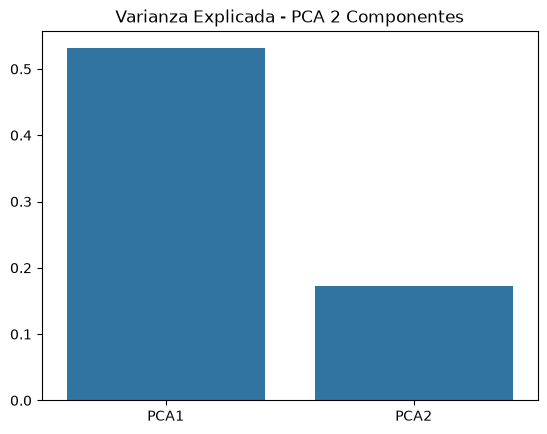

In [17]:
# Graficamos la varianza
sns.barplot(x=['PCA1', 'PCA2'], y=pca2.explained_variance_ratio_)
plt.title('Varianza Explicada - PCA 2 Componentes')
plt.show()

grafica de dispersion

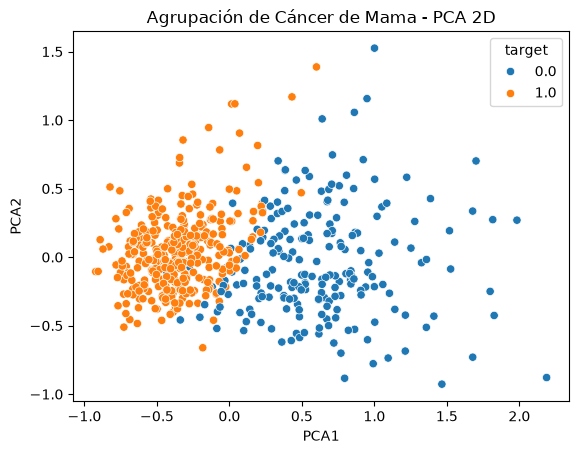

In [ ]:
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='target',
    data=df_pca2
)
plt.title('Agrupación de Cáncer de Mama - PCA 2D')
plt.show()

pca a 3 componentes

In [19]:
# Inicializamos PCA a 3 componentes
pca3 = PCA(n_components=3)



In [20]:
array_pca3 = pca3.fit_transform(df_cancer[cols_mms])

# Armamos un nuevo DataFrame con los componentes y el target
df_pca3 = pd.DataFrame({'PCA1': array_pca3[:, 0],
                        'PCA2': array_pca3[:, 1],
                        'PCA3': array_pca3[:, 2],
                        'target': df_cancer['target']})
df_pca3.head()

,PCA1,PCA2,PCA3,target
0,1.38702,0.426895,-0.541703,0.0
1,0.462308,-0.556947,-0.205175,0.0
2,0.954621,-0.109701,-0.147848,0.0
3,1.00082,1.52509,-0.0532709,0.0
4,0.626828,-0.302471,-0.409336,0.0


In [21]:
varianza_explicada_3 = pca3.explained_variance_ratio_.sum()
print(f"Varianza explicada total (3 componentes): {varianza_explicada_3:.4f}")



Varianza explicada total (3 componentes): 0.7750


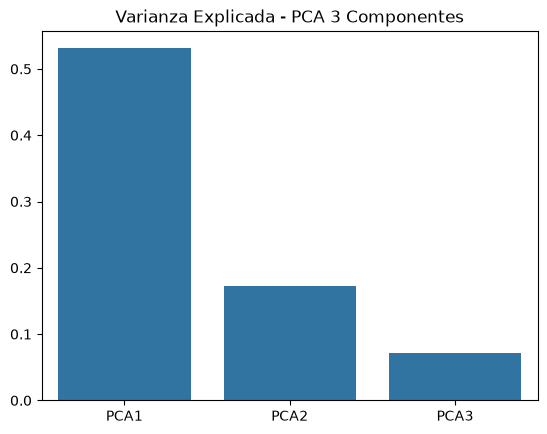

In [22]:
# Grafica de barras de la varianza
sns.barplot(x=['PCA1', 'PCA2', 'PCA3'], y=pca3.explained_variance_ratio_)
plt.title('Varianza Explicada - PCA 3 Componentes')
plt.show()

grafica de 3 dimensiones

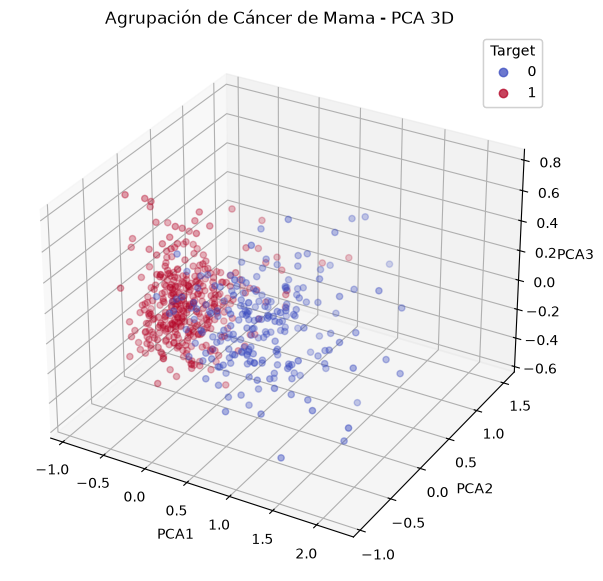

In [23]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Dividimos visualmente en base al target usando cmap
scatter = ax.scatter(df_pca3['PCA1'], df_pca3['PCA2'], df_pca3['PCA3'], 
                     c=df_pca3['target'], cmap='coolwarm', alpha=0.7)

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
plt.title('Agrupación de Cáncer de Mama - PCA 3D')


legend1 = ax.legend(*scatter.legend_elements(), title="Target")
ax.add_artist(legend1)

plt.show()